> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


In [ ]:
# This case needs data files. Colab opens the notebook alone, so fetch them here.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/Index_Tracking_Portfolio/'
FILES = [
    'index_sample.csv',
    'initial_sample.csv',
    'return_sample.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')


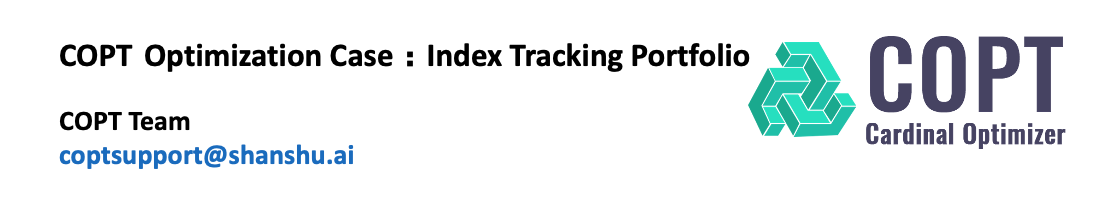

# Code Implementation

## Steps for Optimizing a MIQP Problem

The basic steps for optimizing a MIQP problem using COPT in Python API are as follows:

1. Import the `coptpy` package

2. Add/Import **data**

3. Create **COPT environment** and **COPT model**

4. Construct the model by sequentially adding the **three elements of the model**
    - Add **decision variables**: integer (or 0-1 type) or continuous
    - Set the **quadratic objective function**
    - Add **constraints**
    
5. **Solve** the model

6. View and analyze the **results**

## Add Test Data of the model
Here, we use the return data of the S&P 500 index and the top 50 stocks by weight in the S&P 500 from the end of 2020 to the end of 2023.

**1. Add the list of stocks in the stock pool and their corresponding return rates over this time period**

In [1]:
import pandas as pd
import numpy as np
return_df = pd.read_csv('return_sample.csv')

# Convert the DataFrame into Array which is more suitable for modeling
return_df_arr = np.array(return_df)

# Generate an Array to store Stock Symbols
STOCK_arr = np.array(return_df.columns)

**2. Input the return rates of the S&P 500 index over this time period**

In [3]:
index_df = pd.read_csv('index_sample.csv')
index_df_arr = np.array(index_df)

**3. Input the list of initially selected stocks**

In [5]:
initial_df = pd.read_csv('initial_sample.csv')
initial_df_arr = np.array(initial_df)

**4. Confirm the number of stocks in the stock pool based on the added stock data**

In [7]:
NPERIOD = len(return_df_arr)
NSTOCK = len(STOCK_arr)
print(NSTOCK,NPERIOD)

50 36


**5. Input customized model parameters**

In [13]:
# Set the number of stocks in the portfolio to 4, adjustable based on actual conditions
NSELECT = 4

# Set the turnover rate to 80%, adjustable based on actual conditions
TURNRATE = 0.8

# Set the maximum proportion of each stock in the portfolio. 
# The proportion cannot be less than 1/NSELECT. 
# Pay attention to the relationship between the maximum proportion and TURNRATE to avoid infeasible solutions.
UP_BOUND = 1

## Creating COPT Environment and COPT Model

These are essential steps before invoking COPT for modeling and solving in Python:

In [16]:
import coptpy as cp
from coptpy import COPT 

# Create environment
env = cp.Envr()

# Create model 
model = env.createModel(name="index_tracking")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three elements to construct the model

### Add Decision Variables

1. Add 0-1 variables `z` with type `vtype=COPT.BINARY`.
2. Add continuous variables `w` and `dummy_abs` with type `vtype=COPT.CONTINUOUS`.

In [19]:
w = {}
z = {}
dummy_abs = {}
for i in range (NSTOCK):
    # Add decision variables as stock weights in the portfolio, lb: 0 and ub: UP_BOUND
    w[i] = model.addVar(lb = 0, ub = UP_BOUND, vtype = COPT.CONTINUOUS)
    # Add decision variables indicating whether a stock is selected
    z[i] = model.addVar(vtype = COPT.BINARY)
    # Add auxiliary variables help modeling ABS constraints
    dummy_abs[i] = model.addVar(vtype = COPT.CONTINUOUS)

### Set the objective function

The objective aims to minimize the tracking error, defined as the squared difference between the expected portfolio return and the market return across multiple period, using `sense=COPT.MINIMIZE` to specify the optimization direction.

$$
Minimize \sum_{t \in NPERIOD} (\sum_{i \in STOCK} return_{t,i}\cdot w_i-return_{t,sp})^2 / NPERIOD 
$$

In [23]:
obj = cp.quicksum((cp.quicksum(return_df_arr[t][i] * w[i] for i in range(NSTOCK)) - index_df_arr[t][0]) ** 2 
                  for t in range(NPERIOD))/ NPERIOD
model.setObjective(obj, COPT.MINIMIZE)


<font color=#0000FF>
<b>Tip: Recommended to use quicksum()</b>
</font>

Here, we utilize the COPT tool function `quicksum()` for sum operations. While it performs the same functionality as Python's built-in `sum()` , `quicksum()` is optimized for faster execution and reduced memory usage. It outperforms `sum()` (or directly using the `+` operator) especially in modeling large-scale problems.


### Add Constraints

**1. The sum of the weights of all stocks in the portfolio is 1:**

$$
\sum_{i \in STOCK} w_i = 1
$$

In [28]:
model.addConstr(cp.quicksum(w[i] for i in range(NSTOCK)) == 1)

<coptpy.Constraint: >

**2. The total number of selected stocks does not exceed the custom number of stocks in the portfolio:**

$$
\sum_{i \in STOCK} z_i \leq NSELECT
$$

In [31]:
model.addConstr(cp.quicksum(z[i] for i in range(NSTOCK)) <= NSELECT)

<coptpy.Constraint: >

**3. If stock $i$ is not selected, its weight in the portfolio is 0:**

$$
w_i \le z_i, \hspace{1cm} \forall i \in STOCK
$$

In [34]:
model.addConstrs(w[i] <= z[i] for i in range(NSTOCK))

<font color=#0000FF>
<b>Tips: Another Modeling Approach - Indicator Constraint</b>
</font>

An Indicator is a type of **If-Then** conditional constraint, utilizing a binary variable $y$ as an indicator. 
The value of the variable $y$ determines whether a linear constraint $a^{T}x \leq b$ holds:

$$
\begin{align}
y &= f \rightarrow a^{T}x \leq b\\
f &\in \{0, 1\}
\end{align}
$$

This signifies: if y = 1, then the linear constraint is satisfied.

For If-Then conditional constraints, you can use the Indicator Constraint Builder in COPT, `Model.addGenConstrIndicator()` . Specify the following arguments:

- `binVar`: Binary variable serving as the indicator
- `binval`: Value of the indicator variable in the If condition (0 or 1)
- `builder`: Expression for the linear constraint that holds in the Then conclusion

Implementation example:

```python
for i in range(NSTOCK):
    model.addGenConstrIndicator(z[i], 0, w[i] == 0)
```


**4. The portfolio’s average monthly return must be no less than the market’s average monthly return:**

$$
\frac{(\sum_{t \in NPERIOD}(\sum_{i \in STOCK} return_{t,i}\cdot w_i))}{NPERIOD} \ge \frac{(\sum_{t \in NPERIOD}return_{t,sp})}{NPERIOD}
$$

In [38]:
model.addConstr(cp.quicksum(cp.quicksum(return_df_arr[t][i] * w[i] for i in range(NSTOCK)) for t in range(NPERIOD)) >= \
                cp.quicksum(index_df_arr[t][0] for t in range(NPERIOD)), name="return_lb")

<coptpy.Constraint: return_lb>

**5. To account for rebalancing costs, we set a constraint on the turnover rate. Since buying one stock corresponds to selling another, we divide the number of stocks changed by 2:**

$$
\sum_{i \in STOCK} \frac{|z_i - initial_i|}{2 \cdot NSELECT} \le TURNRATE  
$$

When adding this constraint in Python, we can use the auxiliary variable $dummy\_abs_i$ to convert this constraint into the following two constraints:

$$
\begin{align}
dummy\_{abs}_i &= |z_i - initial_i|, \hspace{1cm} \forall i \in STOCK\\
\sum_{i \in STOCK} dummy\_abs_i &\le 2 \cdot TURNRATE \cdot NSELECT
\end{align}
$$


In [41]:
for i in range(NSTOCK):
    model.addGenConstrAbs(dummy_abs[i], z[i] - initial_df_arr[0][i])
    
model.addConstr(cp.quicksum(dummy_abs[i] for i in range(NSTOCK)) <= 2 * NSELECT * TURNRATE)

<coptpy.Constraint: >

## Solve and View Results

After completing the modeling process, the function `Model.solve()` can be called to solve the model.

In [44]:
model.setParam("RelGap",0)
model.setParam("AbsGap",0)
model.solve()

Setting parameter 'RelGap' to 0
Setting parameter 'AbsGap' to 0
Model fingerprint: d192f9a4

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIQP problem

The original problem has:
    204 rows, 250 columns and 600 non-zero elements
    150 binaries
    100 indicators
    1275 quadratic objective elements

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    90 rows, 172 columns and 1504 non-zero elements
    50 binaries
    36 SOC rows and 108 non-zero elements

Problem info:
    Range of matrix coefficients:    [2e-06,2e+00]
    Range of rhs coefficients:       [4e-03,4e+00]
    Range of bound coefficients:     [2e-05,1e+00]
    Range of cost coefficients:      [2e-03,1e+00]
    Density of cost:                     50.0%

     Nodes    Active  LPit/n 

Finally, based on the results of the optimization, we can print out the selected portfolio, their respective shares, the expected monthly return and the tracking error:

In [46]:
if model.status == COPT.OPTIMAL:
    print("Tracking Error: {:.12f}%".format(model.objval))    
    optimal_return = sum(w[i].x  *  sum(return_df_arr[t][i] for t in range(NPERIOD))/NPERIOD for i in range(NSTOCK))
    print("The expected monthly return of the portfolio: {:.2f}%".format(optimal_return * 100))
    print("-" * 30)
    print("The selected portfolio:")
    for i in range(NSTOCK):
        if w[i].x > 1e-10:
            print('Stock {}: Share {:.2f}%'.format(STOCK_arr[i], w[i].x * 100))

Tracking Error: 0.000118708870%
The expected monthly return of the portfolio: 0.79%
------------------------------
The selected portfolio:
Stock NVDA: Share 15.86%
Stock JNJ: Share 40.95%
Stock HD: Share 18.70%
Stock DIS: Share 24.50%
